# Climate Coding Portfolio Assignment

### *Examining climate records from Missoula, Montana*

<Figure>
  <img
    src="img\post_nyika-campbell-perscribed-burn.JPG"
    alt="Nyika Campbell standing with fuel moisture samples in front of a perscribed fire, 2024"
    width= "25%"
  >
<figcaption>Nyika Campbell collecting samples to measure fuel moisture on a perscribed burn in Missoula, Montana, 2024.</figcaption>
</figure>

In 2026 I worked for the [Missoula Fire Sciences Laboratory](https://research.fs.usda.gov/firelab) leading an ecology monitoring crew. We worked on projects across the state, including a [long-term study](https://research.fs.usda.gov/firelab/projects/lubrecht) quantifying the effectiveness of prescribed burning and thinning on reducing forest fuels. We measured forest fuels, soil chemistry, understory vegetation, and forest structure before and after burning and thinning treatments. We also go to help on prescribed burns! In the picture above I am collecting samples of different fuel classes from inside the fireline during a prescribed burn. This data, along with regularly measured temperature data is used to improve fire behavior models like [Behave](https://research.fs.usda.gov/firelab/products/dataandtools/behave), helping land mangers implement safe and ecologically beneficial fire operations. 

In a 2021 paper, * Quantifying contributions of natural variability and anthropogenic forcings on increased fire weather risk over the western United States * Zhuang et. al found evidence that the dominant control on variation in fire weather (the conditions that pose a risk for increased ignitions and extreme fire) is now anthropogenically forced warming, rather than natural climate fluctuations. In other words, global warming is significantly contributing to the risk of severe fires in the Western United states. 

For this class assignment I thought it would be interesting to look at long-term temperature data in Missoula to see if I could identify noticeable warming in daily mean temperatures, which are one component of ‘fire weather’ calculations.
There are eight NOAA weather stations in Missoula, although only two have data prior to 2001, and only one of those, [MISSOULA 6 NW WEATHER FORECAST OFFICE, MT US](https://www.ncei.noaa.gov/cdo-web/datasets/GHCND/stations/GHCND:USC00245740/detail) station, provides a daily mean temperature metric (TOBS). This station has publicly available temperature data since 1948. In the below code I pull that data and analyze the trends over time.

<Figure>
  <img
    src="img\post_nyika-campbell-perscribed-burn.JPG"
    alt="Screenshot of climate stations in Missoula, MT from https://www.ncei.noaa.gov/"
    width= "25%"
  >
<figcaption>There are eight climate stations in Missoula, MT though mist have only recent data. Image from https://www.ncei.noaa.gov</figcaption>
</figure>


In [16]:
### import data libraries
import earthpy ### manage local data
import pandas as pd ### handle tabular data

## import visualization libraries
import holoviews as hv ### save interactive plots
import hvplot.pandas ### make interactive plots
import hvplot

### import advanced options on matplotlib/seaborn/pandas plots
import matplotlib.pyplot as plt
### common statistical plots for tabular data
import seaborn as sns
### fit an OLS linear regression
from sklearn.linear_model import LinearRegression

### Download the data

In [37]:
### Make url for data
ncei_url = ('https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TOBS&'
            'stations=USC00245740&'
            'startDate=1950-01-01&'
            'endDate=2026-01-01&'
            'units=standard')
ncei_url

 

'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TOBS&stations=USC00245740&startDate=1950-01-01&endDate=2026-01-01&units=standard'

In [38]:
### get the data using the url
### this is a big dataset and took ~3 min to load. Be patient

missoula_df = pd.read_csv(
    ncei_url,

    ### tell python which col to use as index col
    index_col= 'DATE', 

    #### tell python to treat data as a date format
    parse_dates = True,

    ### define the NA values as NaN
    na_values = ['NaN']
    )
missoula_df

,STATION,TOBS
DATE,,
1950-01-01,USC00245740,NaN
1950-01-02,USC00245740,NaN
1950-01-03,USC00245740,-3.0
1950-01-04,USC00245740,6.0
1950-01-05,USC00245740,3.0
...,...,...
2025-12-28,USC00245740,20.0
2025-12-29,USC00245740,20.0
2025-12-30,USC00245740,19.0


<Axes: ylabel='Frequency'>

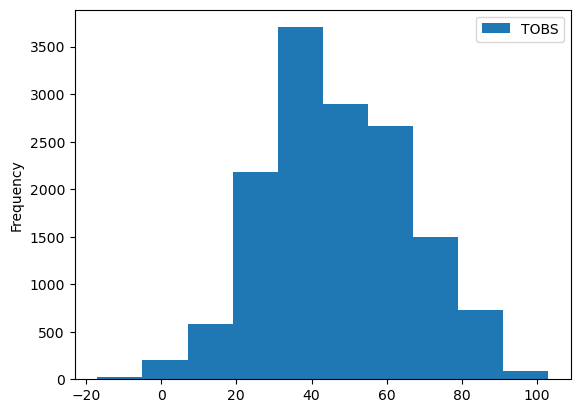

In [39]:
### check that data was imported into a pandas DataFrame
type(missoula_df)

### checek NA handling
missoula_df.plot.hist()

### looks reasonable- 9/28/26 run

### Clean up Data

In [40]:
### Drop unused station variable not needed for this analysis
missoula_temp_df = missoula_df[['TOBS']]
missoula_temp_df

### # check the min and max units to find out what units we are in
missoula_temp_df['TOBS'].agg(['min', 'max'])
### The min and max values are in Fahrenheit. We will convert to Celsius for analysis.

min    -17.0
max    103.0
Name: TOBS, dtype: float64

In [41]:
### change the col names of the temp col to include f for farenheight from documentaion
missoula_temp_df = missoula_temp_df.rename(columns={
    'TOBS': 'temp_f',
})
#missoula_temp_df

In [42]:
### convert f to c nits with a function
def convert_f_to_c(temperature_f):
    """Convert temperature to Celsius"""
    return (temperature_f- 32) *5/9

### apply the function
missoula_temp_df['temp_c'] = (
    missoula_temp_df['temp_f'].apply(convert_f_to_c).round(2))

### inspect result
#missoula_temp_df

### Plot the raw Data

<Axes: title={'center': 'Daily Temperature in Missoula, Montana'}, xlabel='Date', ylabel='Degrees Celcius ($^\\circ$C)'>

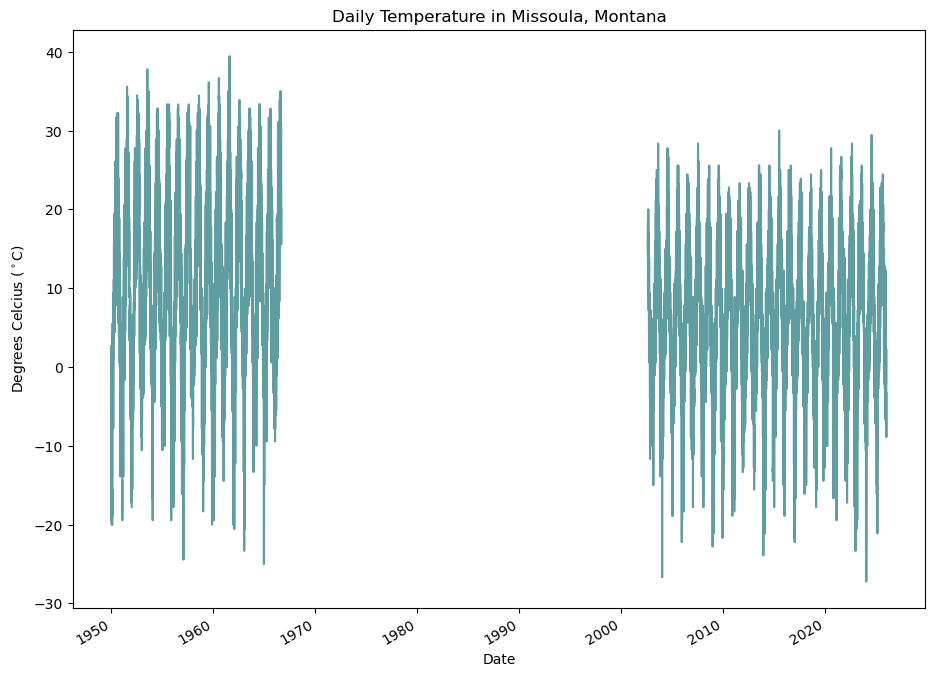

In [43]:
### plot the data in C
missoula_temp_df.plot(
    y = 'temp_c',
    title = 'Daily Temperature in Missoula, Montana',
    xlabel = 'Date',
    ylabel = 'Degrees Celcius ($^\circ$C)',
    figsize = (11,8.5),
    legend=False,
    color = 'cadetblue'
    
)

### Resample and Plot Annually

To get a better sense of the trends over time we plot the mean annual temperatures for the same period.

In [50]:
### Get the mean annual temps

missoula_ann_temp_df = (
    missoula_temp_df

    ### resample annually (assign date on jan 1)
    .resample('YS')

    ### take the mean
    .mean()
)

missoula_ann_temp_df

,temp_f,temp_c
DATE,,
1950-01-01,49.247887,9.582113
1951-01-01,51.075843,10.597640
1952-01-01,53.542466,11.967973
1953-01-01,55.994505,13.330082
1954-01-01,52.294766,11.274821
...,...,...
2022-01-01,41.164384,5.091425
2023-01-01,42.901099,6.055934
2024-01-01,43.482192,6.378767


<Axes: title={'center': 'Annual Temperature in Missoula, Montana'}, xlabel='Year', ylabel='Degrees Celcius ($^\\circ$C)'>

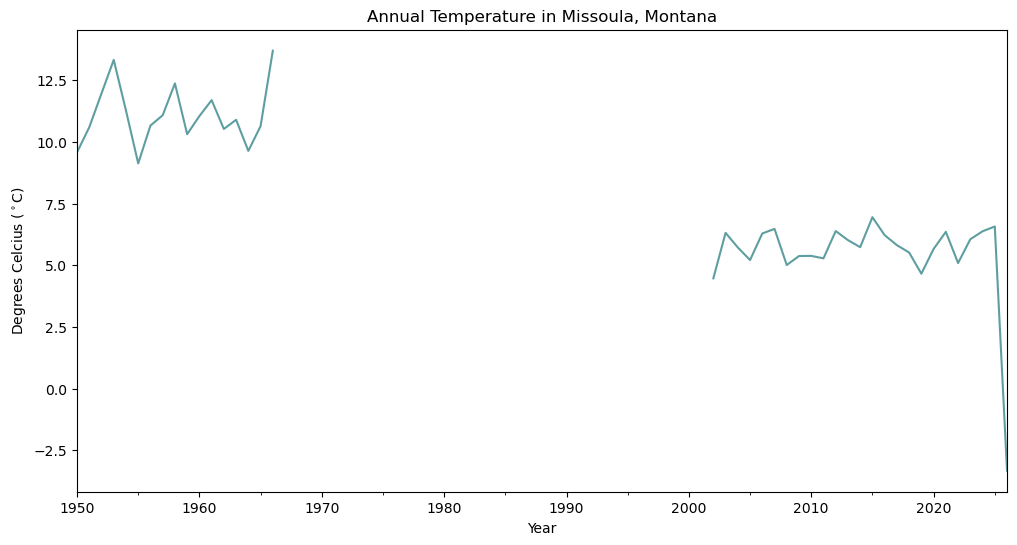

In [51]:
### plot the annual temp in C
missoula_ann_temp_df.plot(
    y = 'temp_c',
    title = 'Annual Temperature in Missoula, Montana',
    xlabel = 'Year',
    ylabel = 'Degrees Celcius ($^\circ$C)',
    figsize = (12,6),
    legend=False,
    color = 'cadetblue'
    
)

In [52]:
### plot the annual data interactively
missoula_ann_temp_plot = missoula_ann_temp_df.hvplot(
    y = 'temp_c',
    title = 'Annual Temperature in Missoula, Montana',
    xlabel = 'Year',
    ylabel = 'Temperature in Degrees Celcius',
    legend=False,
    color = 'cadetblue'
    
)

### View plot
missoula_ann_temp_plot

### Run this fix if the plot is not showing
#hvplot.extension("bokeh")

:Curve   [DATE]   (temp_c)

### Add a trendline
We add a trendline to look at trends over time.

First, we must explore assumptions

* Random error: YES. We assume this is met because we are looking at yearly averages which cover many points each year.
* Normally distributed: YES The histogram shows the average temp are approximately normal.
* Linearity: SORT OF. This is not necessarily true but we assume it for this exercise.
* Stationarity: YES. The variability in the climate seems roughly constant over our time frame.

*The data gap could cause a problem. Lets use only data post-1966*

/opt/conda/lib/python3.11/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


<Axes: xlabel='DATE', ylabel='temp_c'>

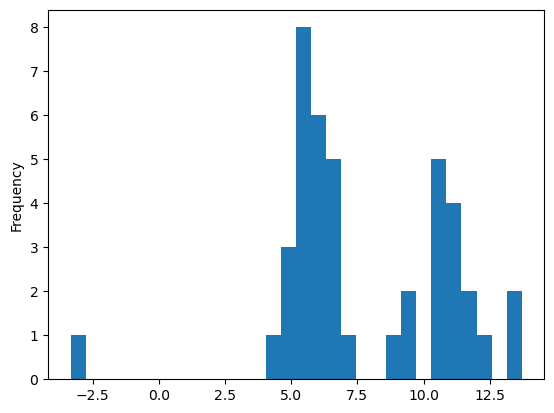

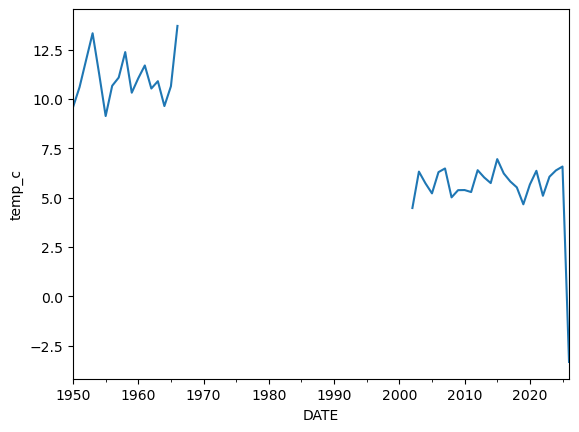

In [53]:
### explore data for assumptions
missoula_ann_temp_df

### historam
missoula_ann_temp_df['temp_c'].plot.hist(bins=30)

### scatter plot
missoula_ann_temp_df.reset_index().plot.scatter(x='DATE', y='temp_c')

#### daily data
missoula_ann_temp_df['temp_c'].plot()

In [54]:
#### Cleaning the data for regression
### Subset to just temp_c data for regression
missoula_ann_c_df = missoula_ann_temp_df[['temp_c']]

### Subset to be just after 2002 years with temperature data
complete_data_df = missoula_ann_c_df.loc['2002':'2026']
complete_data_df

#### drop na in regression_df
regression_df = complete_data_df.dropna()
#regression_df = complete_data_df
regression_df

### Min and max year for regression_df
min_year = regression_df.index.year.min()
max_year = regression_df.index.year.max()
min_year, max_year

### fit an OLS Linear Regression to the data

### define independent variable
### reshape 'year' to be a 2D array (numpy) for scikit-learn
ind_variable = regression_df.index.year.values.reshape(-1, 1)

### define dependent variable
dep_variable = regression_df['temp_c']

### make linear regression model
model = LinearRegression()

### fit the model on the data
model.fit(ind_variable, dep_variable)

### calculate and print metrics
print(f'Slope: {model.coef_[0]} degrees per year')

Slope: -0.06461672980748955 degrees per year


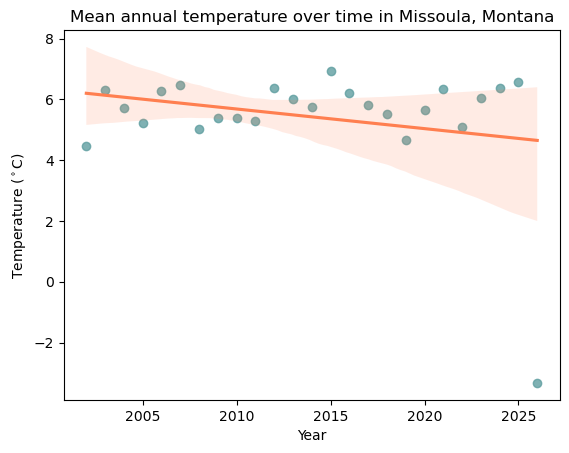

In [55]:
### plot data post 1941 with regression line to ensure slope is what the OLS regression model calculated
ax = sns.regplot(
    x = regression_df.index.year, 
    y = regression_df.temp_c,

    ## change color of datapoints
    color = 'cadetblue',
    ## change color of regression line
    line_kws = {'color': 'coral'},
)

### make labels
ax.set(
    title = 'Mean annual temperature over time in Missoula, Montana',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)

### save your plot
plt.savefig('/workspaces/2026-EDA-climate-change-coding/06_missoula-temperature.jpeg')

### plot it
plt.show()

### An Unexpected Trend

After analyzing temperature data at the [MISSOULA 6 NW WEATHER FORECAST OFFICE, MT US](https://www.ncei.noaa.gov/cdo-web/datasets/GHCND/stations/GHCND:USC00245740/detail)station I was suprized to find that the data had a gap of nearly 36 years from 1966-2002. To prevent this gap from interfering with my trendline analysis I excluded data prior to 2002. However, with such a short time period the fit of the Ordinal Least Squares regression may not be acurate. The OLS trendline indicated a cooling trend of -0.064 degrees per year, or half a degree per decade. Given the overwheming body of scientific research indcating warming trends across the country, and the world, I am concerned this may be a problem with the data. This emphasized the importance of data continuity in long term research.

Cooling in Missoula seemed suspicious to me so I decided to dig deeper. I checked [MISSOULA INTERNATIONAL AIRPORT](https://www.ncei.noaa.gov/cdo-web/datasets/GHCND/stations/GHCND:USW00024153/detail) station and pulled more temperature metrics including daily max and minimum temperatures.





In [45]:
### Pull more kinds of data types, and switch stations
data_types = "TOBS,TMAX,TMIN,PRCP,SNOW,SNWD"

ncei2_url = (
    "https://www.ncei.noaa.gov/access/services/data/v1?"
    f"dataset=daily-summaries&dataTypes={data_types}&"
    "stations=USW00024153&"
    "startDate=1950-01-01&"
    "endDate=2026-01-01&"
    "units=standard"
)

ncei_url

'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TOBS&stations=USC00245740&startDate=1950-01-01&endDate=2026-01-01&units=standard'

In [ ]:
### get the data using the url

missoula2_df = pd.read_csv(
    ncei2_url,

    ### tell python which col to use as index col
    index_col= 'DATE', 

    #### tell python to treat data as a date format
    parse_dates = True,

    ### define the NA values as NaN
    na_values = ['NaN']
    )
missoula2_df



,STATION,PRCP,SNOW,SNWD,TMAX,TMIN,TOBS
DATE,,,,,,,
1950-01-01,USW00024153,0.05,1.0,1.0,25,7,NaN
1950-01-02,USW00024153,0.00,0.1,1.0,18,-7,NaN
1950-01-03,USW00024153,0.00,0.0,1.0,3,-10,NaN
1950-01-04,USW00024153,0.04,0.4,1.0,11,-5,NaN
1950-01-05,USW00024153,0.00,0.0,1.0,7,-13,NaN
...,...,...,...,...,...,...,...
2025-12-28,USW00024153,0.00,0.0,1.0,22,7,NaN
2025-12-29,USW00024153,0.00,0.0,1.0,31,18,NaN
2025-12-30,USW00024153,0.00,0.0,1.0,32,15,NaN


<Axes: title={'center': 'Max Temperature in Missoula, Montana'}, xlabel='Date', ylabel='Degrees F ($^\\circ$C)'>

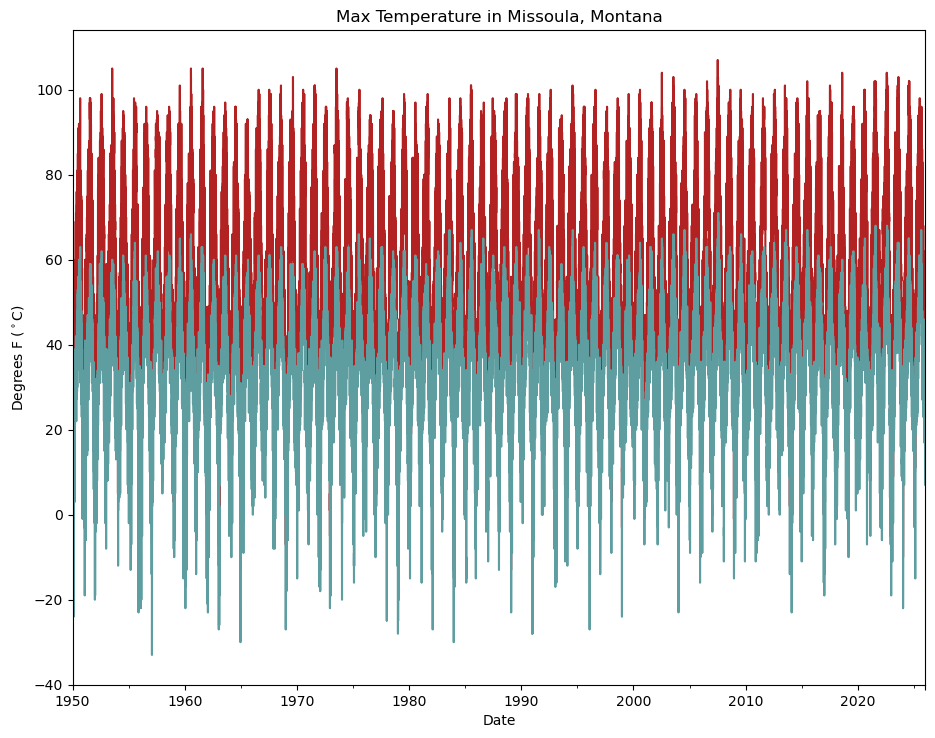

In [ ]:
### plot the data in C
missoula2_df.plot(
    y = ["TMAX", "TMIN"],
    title = 'Max (red) and Min (blue)Temperature in Missoula, Montana',
    xlabel = 'Date',
    ylabel = 'Degrees F ($^\circ$C)',
    figsize = (11,8.5),
    legend=False,
    color = ["firebrick", "cadetblue"],
    
)

## we have good data continuity on these metrics

### Sources

Zhuang, Y., Fu, R., Santer, B. D., Dickinson, R. E., & Hall, A. (2021). Quantifying contributions of natural variability and anthropogenic forcings on increased fire weather risk over the western United States. *Proceedings of the National Academy of Sciences, 118*(45), e2111875118. https://doi.org/10.1073/pnas.2111875118
